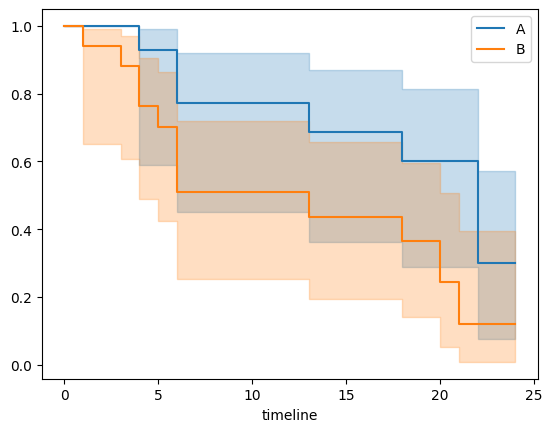

In [5]:
import lifelines
import pandas as pd

# Setup data
data = {
    'time': [4, 5, 6, 6, 6, 13, 18, 18, 22, 22, 22, 22, 24, 24, 
             1, 3, 4, 4, 4, 5, 6, 6, 6, 6, 13, 18, 18, 18, 20, 21, 24],
    'event': [1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 
              1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0],
    'group': ['A']*14 + ['B']*17
}
df = pd.DataFrame(data)

# KM Plot
kmf = lifelines.KaplanMeierFitter()
for name, grouped_df in df.groupby('group'):
    kmf.fit(grouped_df['time'], grouped_df['event'], label=name)
    kmf.plot_survival_function()

# Log-rank test
from lifelines.statistics import logrank_test

# Group A: 14 observations
# 4, 6, 13, 18, 22, 22, 22 (Events = 1)
# 5, 6, 18, 22, 24, 24 (Censored = 0)
durations_A = [4, 5, 6, 6, 6, 13, 18, 18, 22, 22, 22, 22, 24, 24]
event_observed_A = [1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0]

# Group B: 17 observations
# 1, 3, 4, 4, 5, 6, 6, 6, 13, 18, 20, 21 (Events = 1)
# 4, 6, 18, 18, 24 (Censored = 0)
durations_B = [1, 3, 4, 4, 4, 5, 6, 6, 6, 6, 13, 18, 18, 18, 20, 21, 24]
event_observed_B = [1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0]

# Running the log-rank test
results = logrank_test(durations_A, durations_B, event_observed_A, event_observed_B)

# Displaying the results
results.print_summary()